In [1]:
import pandas as pd
import numpy as np

import sys
import warnings
import itertools
warnings.filterwarnings("ignore")

In [2]:
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path="/content/drive/MyDrive/PDSBA/CPN1/PD_modelling.xlsx"

df=pd.read_excel(path)

Mounted at /content/drive


In [4]:
sns.set()
sns.set_palette(palette='deep')
import folium
from folium.plugins import FastMarkerCluster

In [5]:
df.head().T

,0,1,2,3,4
userid,4567129.0,2635118.0,4804232.0,1442693.0,4575322.0
default,0.0,0.0,0.0,0.0,0.0
acct_amt_added_12_24m,0.0,0.0,0.0,0.0,0.0
acct_days_in_dc_12_24m,0.0,0.0,0.0,NaN,0.0
acct_days_in_rem_12_24m,0.0,0.0,0.0,NaN,0.0
acct_days_in_term_12_24m,0.0,0.0,0.0,NaN,0.0
acct_incoming_debt_vs_paid_0_24m,0.0,NaN,NaN,NaN,NaN
acct_status,1.0,1.0,NaN,NaN,NaN
acct_worst_status_0_3m,1.0,1.0,NaN,NaN,NaN
acct_worst_status_12_24m,NaN,1.0,NaN,NaN,NaN


In [6]:
df.tail().T

,99974,99975,99976,99977,99978
userid,4648093.0,1247657.0,NaN,NaN,0.0
default,NaN,NaN,NaN,NaN,10000.0
acct_amt_added_12_24m,56102.0,0.0,NaN,NaN,0.0
acct_days_in_dc_12_24m,0.0,0.0,NaN,NaN,11836.0
acct_days_in_rem_12_24m,0.0,0.0,NaN,NaN,11836.0
acct_days_in_term_12_24m,0.0,0.0,NaN,NaN,11836.0
acct_incoming_debt_vs_paid_0_24m,0.064175,NaN,NaN,NaN,59315.0
acct_status,1.0,1.0,NaN,NaN,54373.0
acct_worst_status_0_3m,2.0,1.0,NaN,NaN,54373.0
acct_worst_status_12_24m,1.0,NaN,NaN,NaN,66761.0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
userid,99977.0,2.998947e+06,1.154211e+06,0.0,2.000260e+06,2.998815e+06,4.000633e+06,4.999868e+06
default,89977.0,1.254543e-01,3.333776e+01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+04
acct_amt_added_12_24m,99977.0,1.225503e+04,3.548133e+04,0.0,0.000000e+00,0.000000e+00,4.937000e+03,1.128775e+06
acct_days_in_dc_12_24m,88141.0,3.573252e-01,4.028733e+01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.183600e+04
acct_days_in_rem_12_24m,88141.0,5.178850e+00,4.594340e+01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.183600e+04
acct_days_in_term_12_24m,88141.0,4.211774e-01,3.997377e+01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.183600e+04
acct_incoming_debt_vs_paid_0_24m,40662.0,2.789992e+00,2.953340e+02,0.0,0.000000e+00,1.520899e-01,6.629926e-01,5.931500e+04
acct_status,45604.0,2.234431e+00,2.546089e+02,1.0,1.000000e+00,1.000000e+00,1.000000e+00,5.437300e+04
acct_worst_status_0_3m,45604.0,2.365165e+00,2.546086e+02,1.0,1.000000e+00,1.000000e+00,1.000000e+00,5.437300e+04
acct_worst_status_12_24m,33216.0,3.347212e+00,3.663034e+02,1.0,1.000000e+00,1.000000e+00,2.000000e+00,6.676100e+04


In [8]:
df.shape

(99979, 36)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99979 entries, 0 to 99978
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   userid                            99977 non-null  float64
 1   default                           89977 non-null  float64
 2   acct_amt_added_12_24m             99977 non-null  float64
 3   acct_days_in_dc_12_24m            88141 non-null  float64
 4   acct_days_in_rem_12_24m           88141 non-null  float64
 5   acct_days_in_term_12_24m          88141 non-null  float64
 6   acct_incoming_debt_vs_paid_0_24m  40662 non-null  float64
 7   acct_status                       45604 non-null  float64
 8   acct_worst_status_0_3m            45604 non-null  float64
 9   acct_worst_status_12_24m          33216 non-null  float64
 10  acct_worst_status_3_6m            42275 non-null  float64
 11  acct_worst_status_6_12m           39627 non-null  float64
 12  age 

In [10]:
print("\nInformation about the index of the dataset:")
print(df.index)


Information about the index of the dataset:
RangeIndex(start=0, stop=99979, step=1)


In [11]:
print("\nColumn names of the dataset:")
print(df.columns)


Column names of the dataset:
Index(['userid', 'default', 'acct_amt_added_12_24m', 'acct_days_in_dc_12_24m',
       'acct_days_in_rem_12_24m', 'acct_days_in_term_12_24m',
       'acct_incoming_debt_vs_paid_0_24m', 'acct_status',
       'acct_worst_status_0_3m', 'acct_worst_status_12_24m',
       'acct_worst_status_3_6m', 'acct_worst_status_6_12m', 'age',
       'avg_payment_span_0_12m', 'avg_payment_span_0_3m', 'merchant_category',
       'merchant_group', 'has_paid', 'max_paid_inv_0_12m',
       'max_paid_inv_0_24m', 'name_in_email',
       'num_active_div_by_paid_inv_0_12m', 'num_active_inv',
       'num_arch_dc_0_12m', 'num_arch_dc_12_24m', 'num_arch_ok_0_12m',
       'num_arch_ok_12_24m', 'num_arch_rem_0_12m',
       'status_max_archived_0_6_months', 'status_max_archived_0_12_months',
       'status_max_archived_0_24_months', 'recovery_debt',
       'sum_capital_paid_acct_0_12m', 'sum_capital_paid_acct_12_24m',
       'sum_paid_inv_0_12m', 'time_hours'],
      dtype='object')


In [12]:
print(df.dtypes)

userid                              float64
default                             float64
acct_amt_added_12_24m               float64
acct_days_in_dc_12_24m              float64
acct_days_in_rem_12_24m             float64
acct_days_in_term_12_24m            float64
acct_incoming_debt_vs_paid_0_24m    float64
acct_status                         float64
acct_worst_status_0_3m              float64
acct_worst_status_12_24m            float64
acct_worst_status_3_6m              float64
acct_worst_status_6_12m             float64
age                                 float64
avg_payment_span_0_12m              float64
avg_payment_span_0_3m               float64
merchant_category                    object
merchant_group                       object
has_paid                            float64
max_paid_inv_0_12m                  float64
max_paid_inv_0_24m                  float64
name_in_email                        object
num_active_div_by_paid_inv_0_12m    float64
num_active_inv                  

In [13]:
renamed_columns = {
    "acct_amt_added_12_24m": "total_purchases_12_24m",
    "acct_days_in_dc_12_24m": "days_in_debt_collection_12_24m",
    "acct_days_in_rem_12_24m": "days_in_reminder_12_24m",
    "acct_days_in_term_12_24m": "days_in_termination_12_24m",
    "acct_incoming_debt_vs_paid_0_24m": "debt_vs_paid_ratio_0_24m",
    "acct_status": "account_status",
    "acct_worst_status_0_3m": "worst_status_0_3m",
    "acct_worst_status_12_24m": "worst_status_12_24m",
    "acct_worst_status_3_6m": "worst_status_3_6m",
    "acct_worst_status_6_12m": "worst_status_6_12m",
    "avg_payment_span_0_12m": "avg_payment_span_0_12m",
    "avg_payment_span_0_3m": "avg_payment_span_0_3m",
    "merchant_category": "merchant_category",
    "merchant_group": "merchant_group",
    "has_paid": "has_paid",
    "max_paid_inv_0_12m": "max_paid_inv_0_12m",
    "max_paid_inv_0_24m": "max_paid_inv_0_24m",
    "name_in_email": "name_in_email",
    "num_active_div_by_paid_inv_0_12m": "active_div_by_paid_ratio_0_12m",
    "num_active_inv": "num_active_invoices",
    "num_arch_dc_0_12m": "num_arch_dc_0_12m",
    "num_arch_dc_12_24m": "num_arch_dc_12_24m",
    "num_arch_ok_0_12m": "num_arch_ok_0_12m",
    "num_arch_ok_12_24m": "num_arch_ok_12_24m",
    "num_arch_rem_0_12m": "num_arch_rem_0_12m",
    "status_max_archived_0_6_months": "max_archived_status_0_6_months",
    "status_max_archived_0_12_months": "max_archived_status_0_12_months",
    "status_max_archived_0_24_months": "max_archived_status_0_24_months",
    "recovery_debt": "recovery_debt",
    "sum_capital_paid_acct_0_12m": "sum_capital_paid_acct_0_12m",
    "sum_capital_paid_acct_12_24m": "sum_capital_paid_acct_12_24m",
    "sum_paid_inv_0_12m": "sum_paid_inv_0_12m",
    "time_hours": "time_hours"
}

df.rename(columns=renamed_columns, inplace=True)

print("\nFirst few rows of the updated dataset:")
print(df.head())


First few rows of the updated dataset:
      userid  default  total_purchases_12_24m  days_in_debt_collection_12_24m  \
0  4567129.0      0.0                     0.0                             0.0   
1  2635118.0      0.0                     0.0                             0.0   
2  4804232.0      0.0                     0.0                             0.0   
3  1442693.0      0.0                     0.0                             NaN   
4  4575322.0      0.0                     0.0                             0.0   

   days_in_reminder_12_24m  days_in_termination_12_24m  \
0                      0.0                         0.0   
1                      0.0                         0.0   
2                      0.0                         0.0   
3                      NaN                         NaN   
4                      0.0                         0.0   

   debt_vs_paid_ratio_0_24m  account_status  worst_status_0_3m  \
0                       0.0             1.0               

In [18]:
print(df.columns)

Index(['userid', 'default', 'total_purchases_12_24m',
       'days_in_debt_collection_12_24m', 'days_in_reminder_12_24m',
       'days_in_termination_12_24m', 'debt_vs_paid_ratio_0_24m',
       'account_status', 'worst_status_0_3m', 'worst_status_12_24m',
       'worst_status_3_6m', 'worst_status_6_12m', 'age',
       'avg_payment_span_0_12m', 'avg_payment_span_0_3m', 'merchant_category',
       'merchant_group', 'has_paid', 'max_paid_inv_0_12m',
       'max_paid_inv_0_24m', 'name_in_email', 'active_div_by_paid_ratio_0_12m',
       'num_active_invoices', 'num_arch_dc_0_12m', 'num_arch_dc_12_24m',
       'num_arch_ok_0_12m', 'num_arch_ok_12_24m', 'num_arch_rem_0_12m',
       'max_archived_status_0_6_months', 'max_archived_status_0_12_months',
       'max_archived_status_0_24_months', 'recovery_debt',
       'sum_capital_paid_acct_0_12m', 'sum_capital_paid_acct_12_24m',
       'sum_paid_inv_0_12m', 'time_hours'],
      dtype='object')


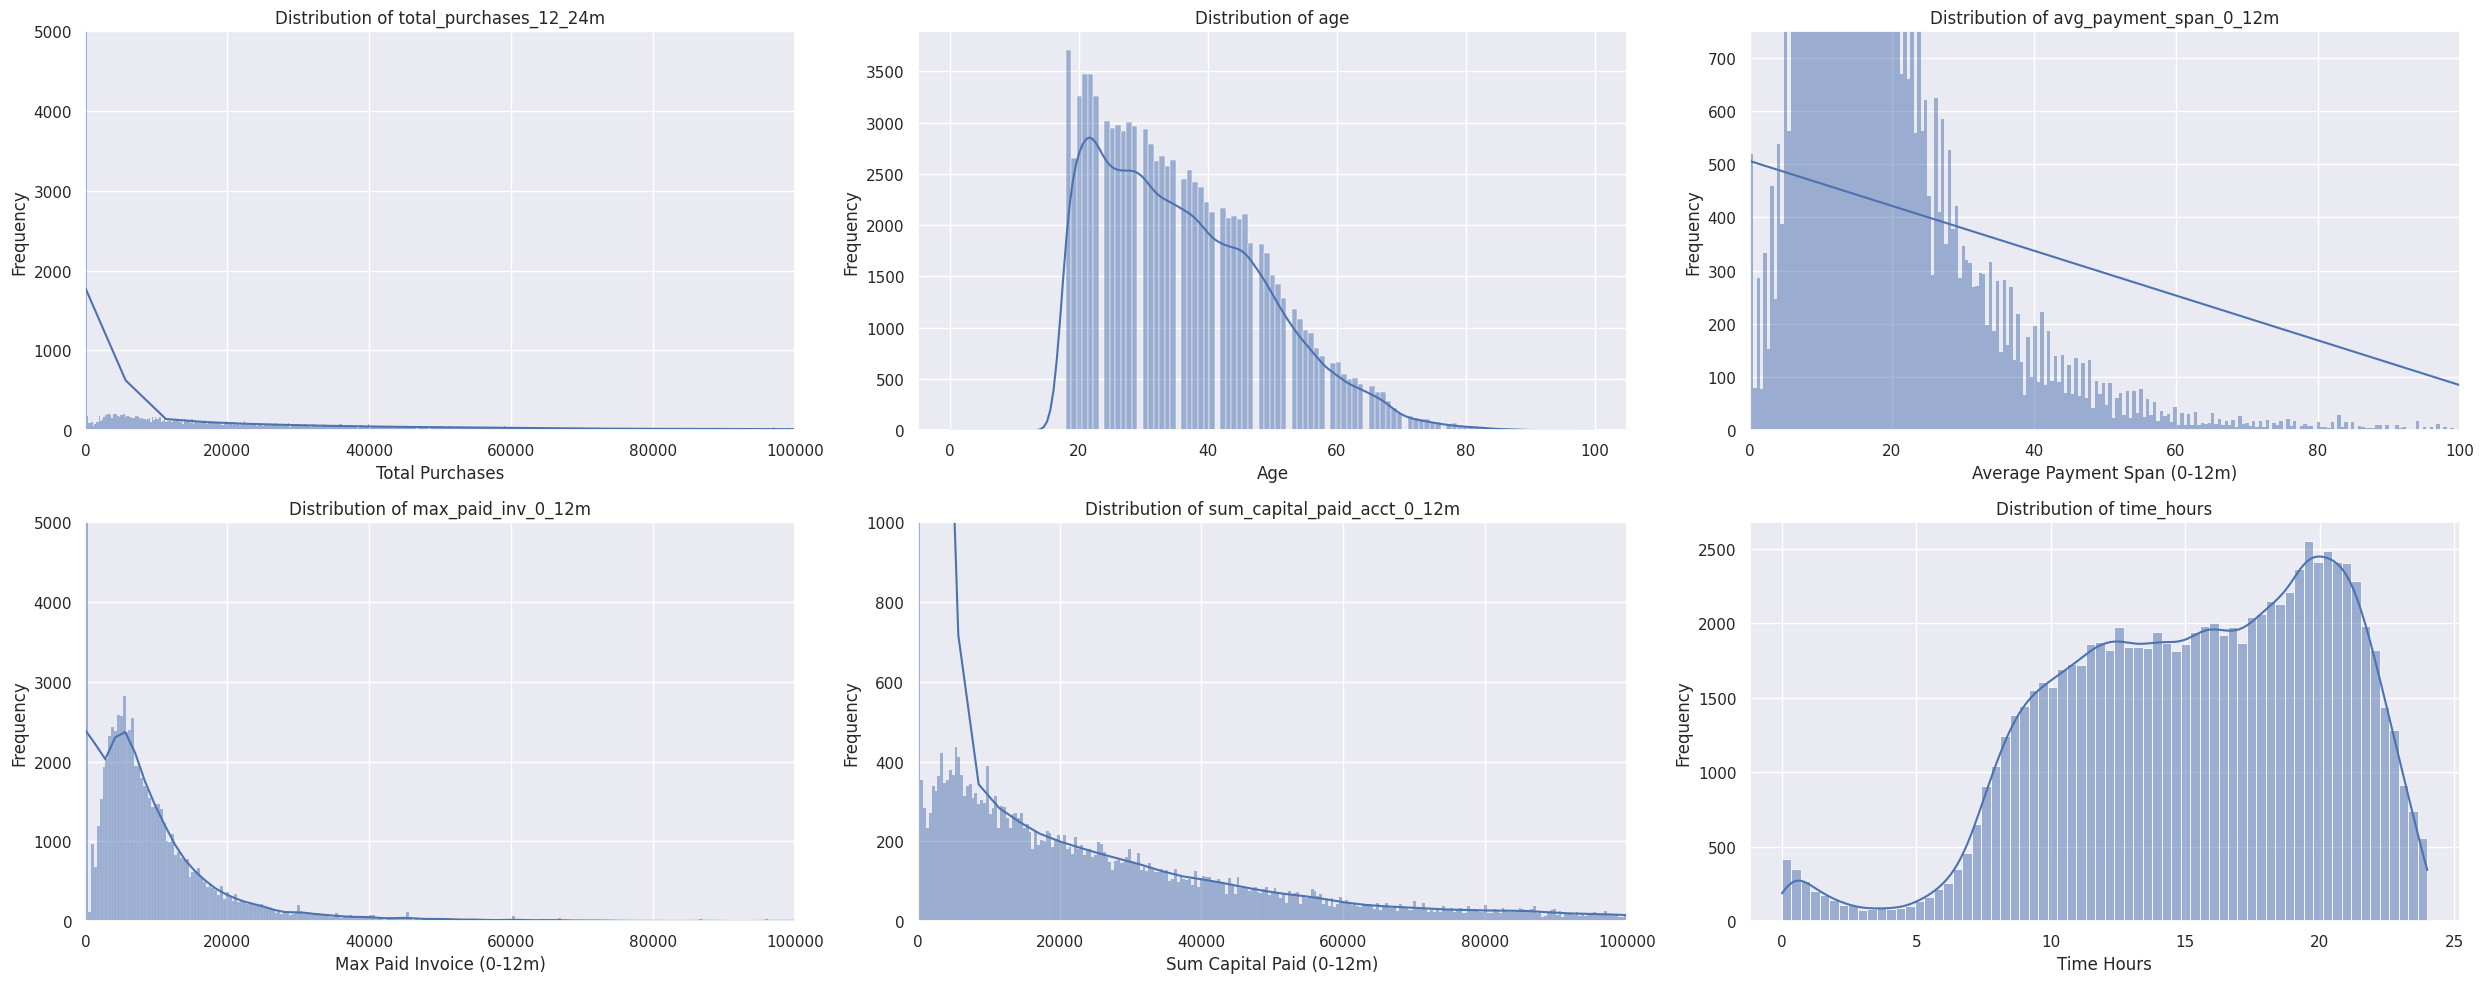

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_attributes = ['total_purchases_12_24m', 'age', 'avg_payment_span_0_12m',
                         'max_paid_inv_0_12m', 'sum_capital_paid_acct_0_12m', 'time_hours']

categorical_attributes = ['has_paid', 'merchant_category', 'merchant_group']

plt.figure(figsize=(25, 10))

plt.subplot(2, 3, 1)
sns.histplot(df['total_purchases_12_24m'], kde=True)
plt.title('Distribution of total_purchases_12_24m')
plt.xlabel('Total Purchases')
plt.ylabel('Frequency')
plt.ylim(0, 5000)
plt.xlim(0,100000)

plt.subplot(2, 3, 2)
sns.histplot(df['age'], kde=True)
plt.title('Distribution of age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(2, 3, 3)
sns.histplot(df['avg_payment_span_0_12m'], kde=True)
plt.title('Distribution of avg_payment_span_0_12m')
plt.xlabel('Average Payment Span (0-12m)')
plt.ylabel('Frequency')
plt.ylim(0, 750)
plt.xlim(0,100)

plt.subplot(2, 3, 4)
sns.histplot(df['max_paid_inv_0_12m'], kde=True)
plt.title('Distribution of max_paid_inv_0_12m')
plt.xlabel('Max Paid Invoice (0-12m)')
plt.ylabel('Frequency')
plt.ylim(0, 5000)
plt.xlim(0,100000)

plt.subplot(2, 3, 5)
sns.histplot(df['sum_capital_paid_acct_0_12m'], kde=True)
plt.title('Distribution of sum_capital_paid_acct_0_12m')
plt.xlabel('Sum Capital Paid (0-12m)')
plt.ylabel('Frequency')
plt.ylim(0, 1000)
plt.xlim(0,100000)

plt.subplot(2, 3, 6)
sns.histplot(df['time_hours'], kde=True)
plt.title('Distribution of time_hours')
plt.xlabel('Time Hours')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

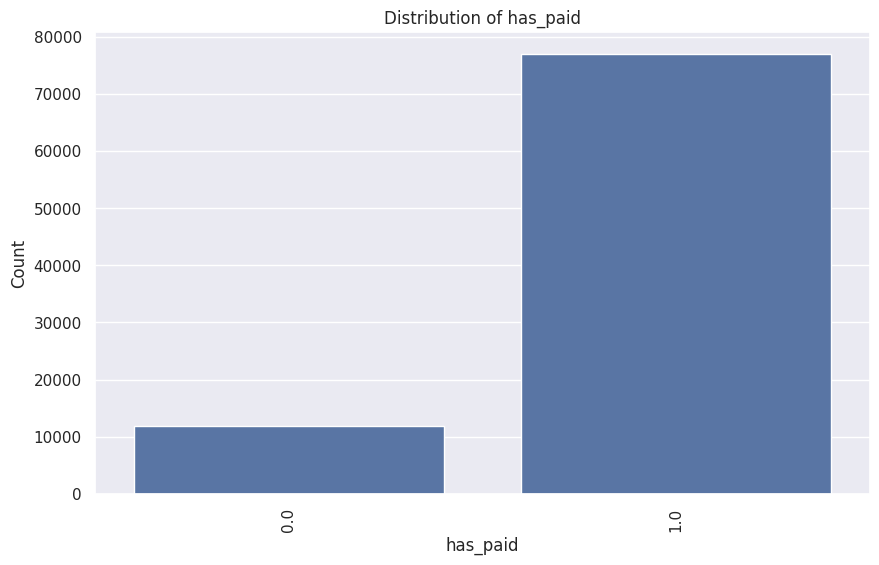

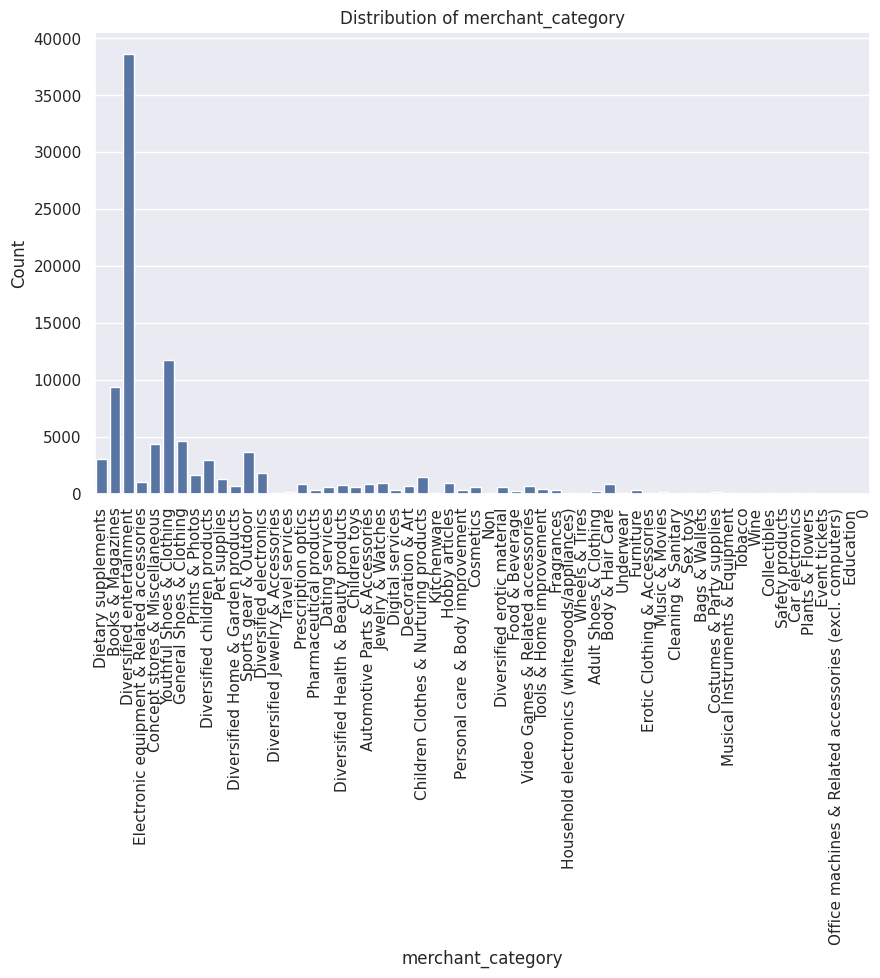

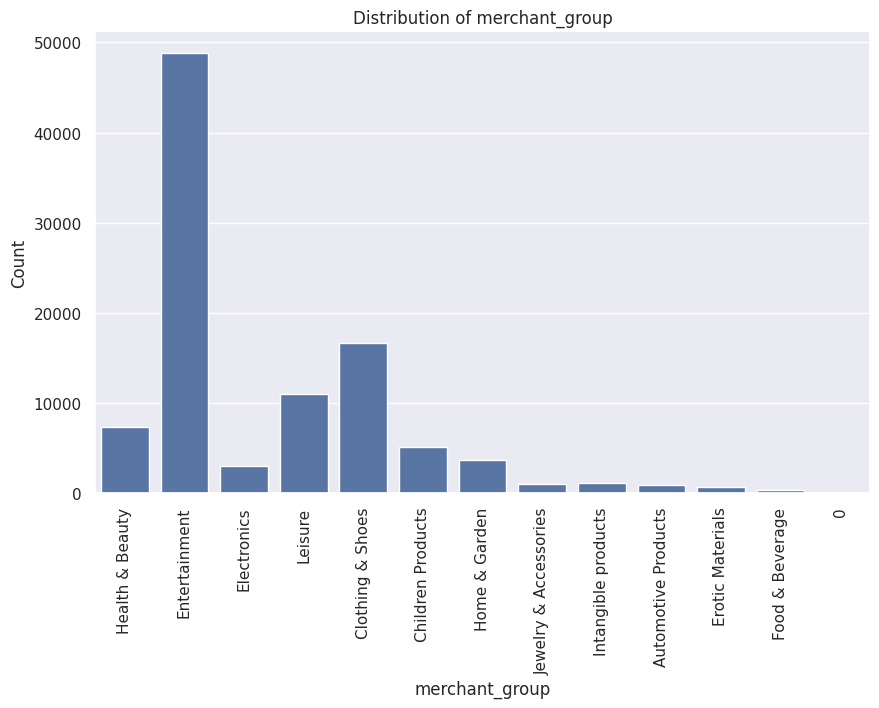

In [20]:
for col in categorical_attributes:
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.show()


In [21]:
dfna = df.isna().sum()
dfna[dfna.values > 0].sort_values(ascending=False)

worst_status_12_24m                66763
worst_status_6_12m                 60352
debt_vs_paid_ratio_0_24m           59317
worst_status_3_6m                  57704
worst_status_0_3m                  54375
account_status                     54375
avg_payment_span_0_3m              49307
active_div_by_paid_ratio_0_12m     29927
avg_payment_span_0_12m             23838
days_in_debt_collection_12_24m     11838
days_in_reminder_12_24m            11838
days_in_termination_12_24m         11838
num_arch_rem_0_12m                 11036
max_paid_inv_0_12m                 11036
max_archived_status_0_12_months    11036
num_arch_ok_12_24m                 11036
max_archived_status_0_6_months     11036
sum_capital_paid_acct_12_24m       11036
max_archived_status_0_24_months    11036
recovery_debt                      11036
sum_capital_paid_acct_0_12m        11036
num_arch_dc_12_24m                 11036
sum_paid_inv_0_12m                 11036
num_arch_ok_0_12m                  11036
time_hours      

In [22]:
print(df['merchant_category'].value_counts())

Diversified entertainment                                  38614
Youthful Shoes & Clothing                                  11755
Books & Magazines                                           9363
General Shoes & Clothing                                    4597
Concept stores & Miscellaneous                              4406
Sports gear & Outdoor                                       3712
Dietary supplements                                         3101
Diversified children products                               2994
Diversified electronics                                     1844
Prints & Photos                                             1675
Children Clothes & Nurturing products                       1500
Pet supplies                                                1315
Electronic equipment & Related accessories                  1037
Jewelry & Watches                                            911
Hobby articles                                               910
Prescription optics      

In [23]:
print(df['default'].value_counts())

0.0        88688
1.0         1288
10000.0        1
Name: default, dtype: int64


In [24]:
print(df.groupby('default')['age'].mean())

default
0.0        36.087554
1.0        31.302019
10000.0     0.000000
Name: age, dtype: float64


In [25]:
print(df['age'].describe())

count    99977.000000
mean        36.015924
std         13.001740
min          0.000000
25%         25.000000
50%         34.000000
75%         45.000000
max        100.000000
Name: age, dtype: float64


In [26]:
print(df['has_paid'].value_counts())

1.0    77002
0.0    11941
Name: has_paid, dtype: int64


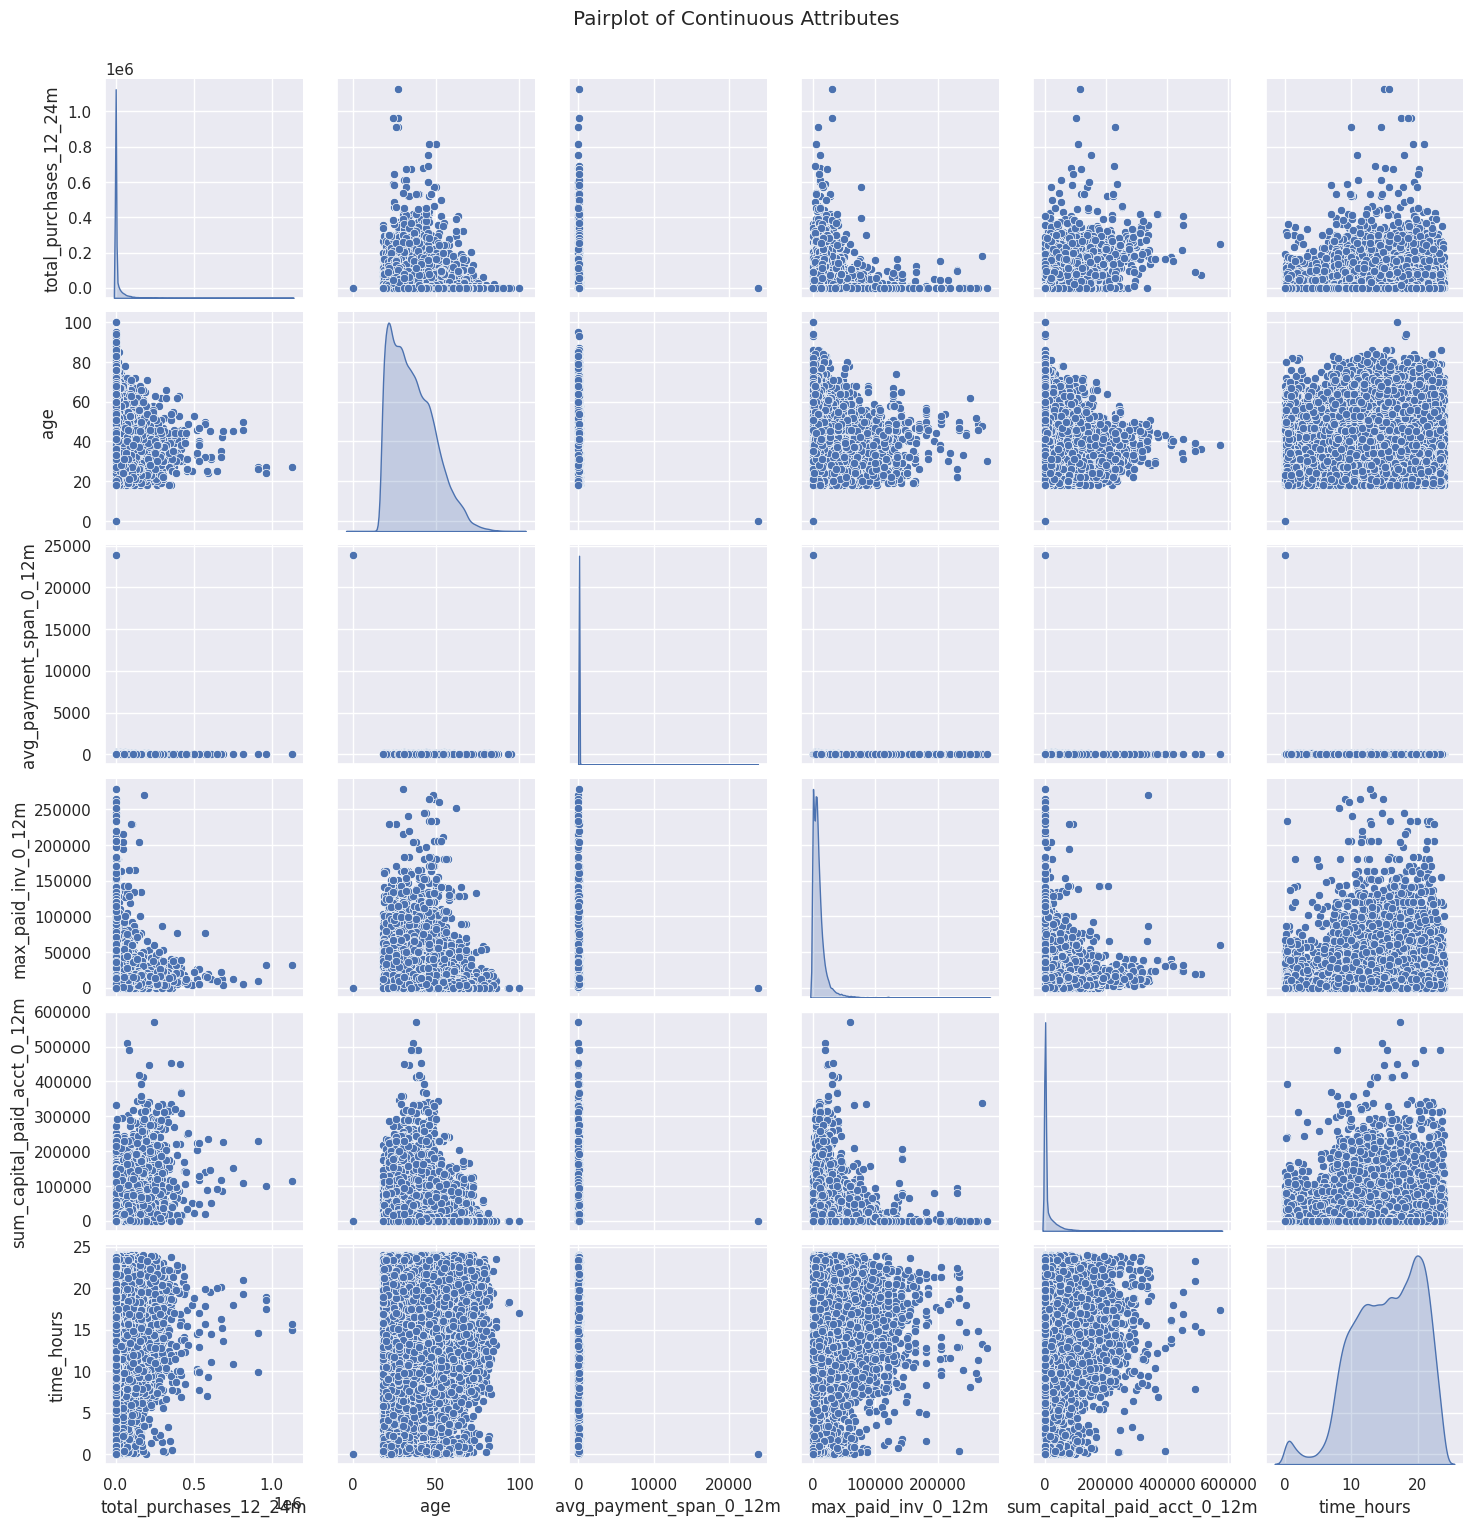

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

all_attributes = continuous_attributes + categorical_attributes

correlation_matrix = df[all_attributes].corr()

sns.pairplot(df[continuous_attributes], diag_kind='kde')
plt.suptitle('Pairplot of Continuous Attributes', y=1.02)
plt.show()

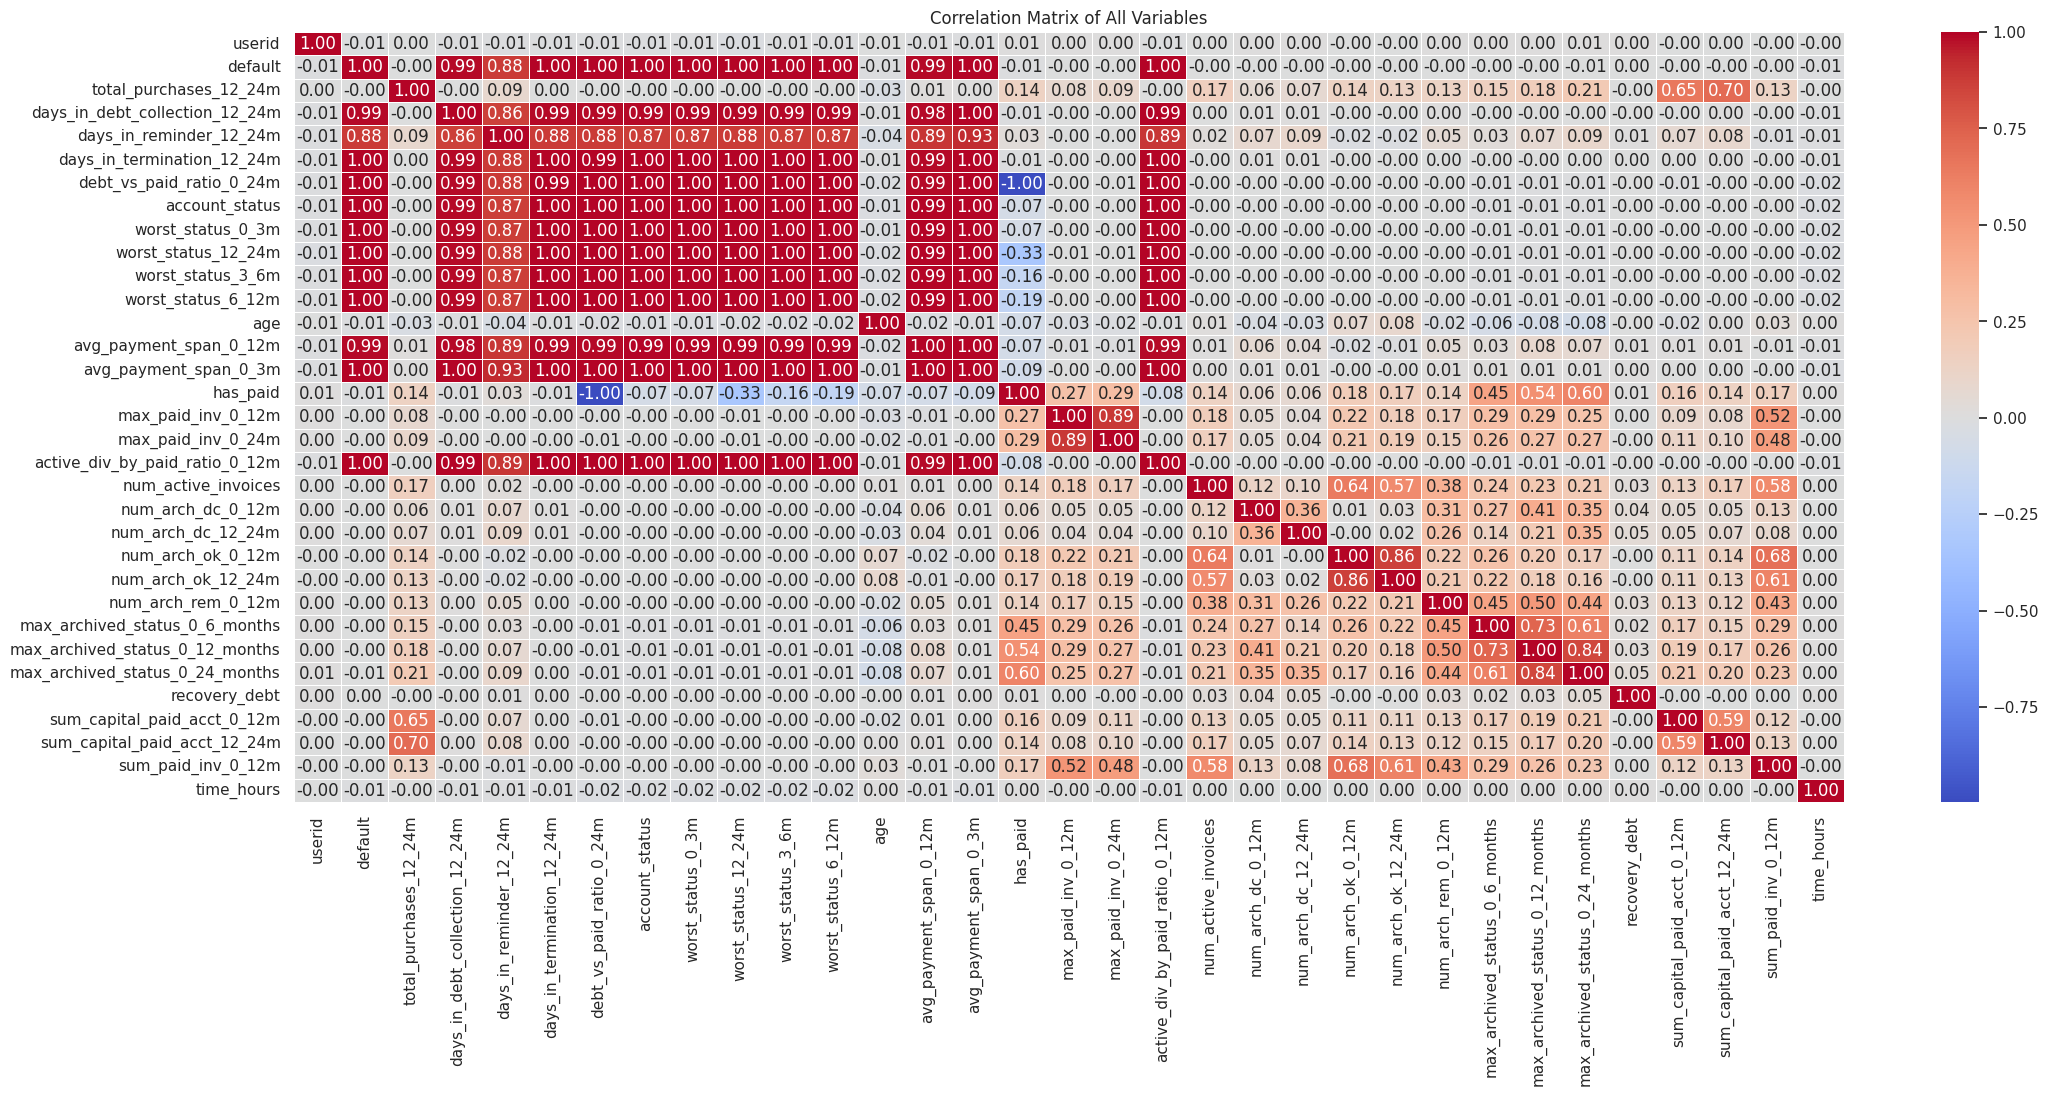

In [28]:
correlation_matrix = df.corr()

plt.figure(figsize=(25, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of All Variables')
plt.show()

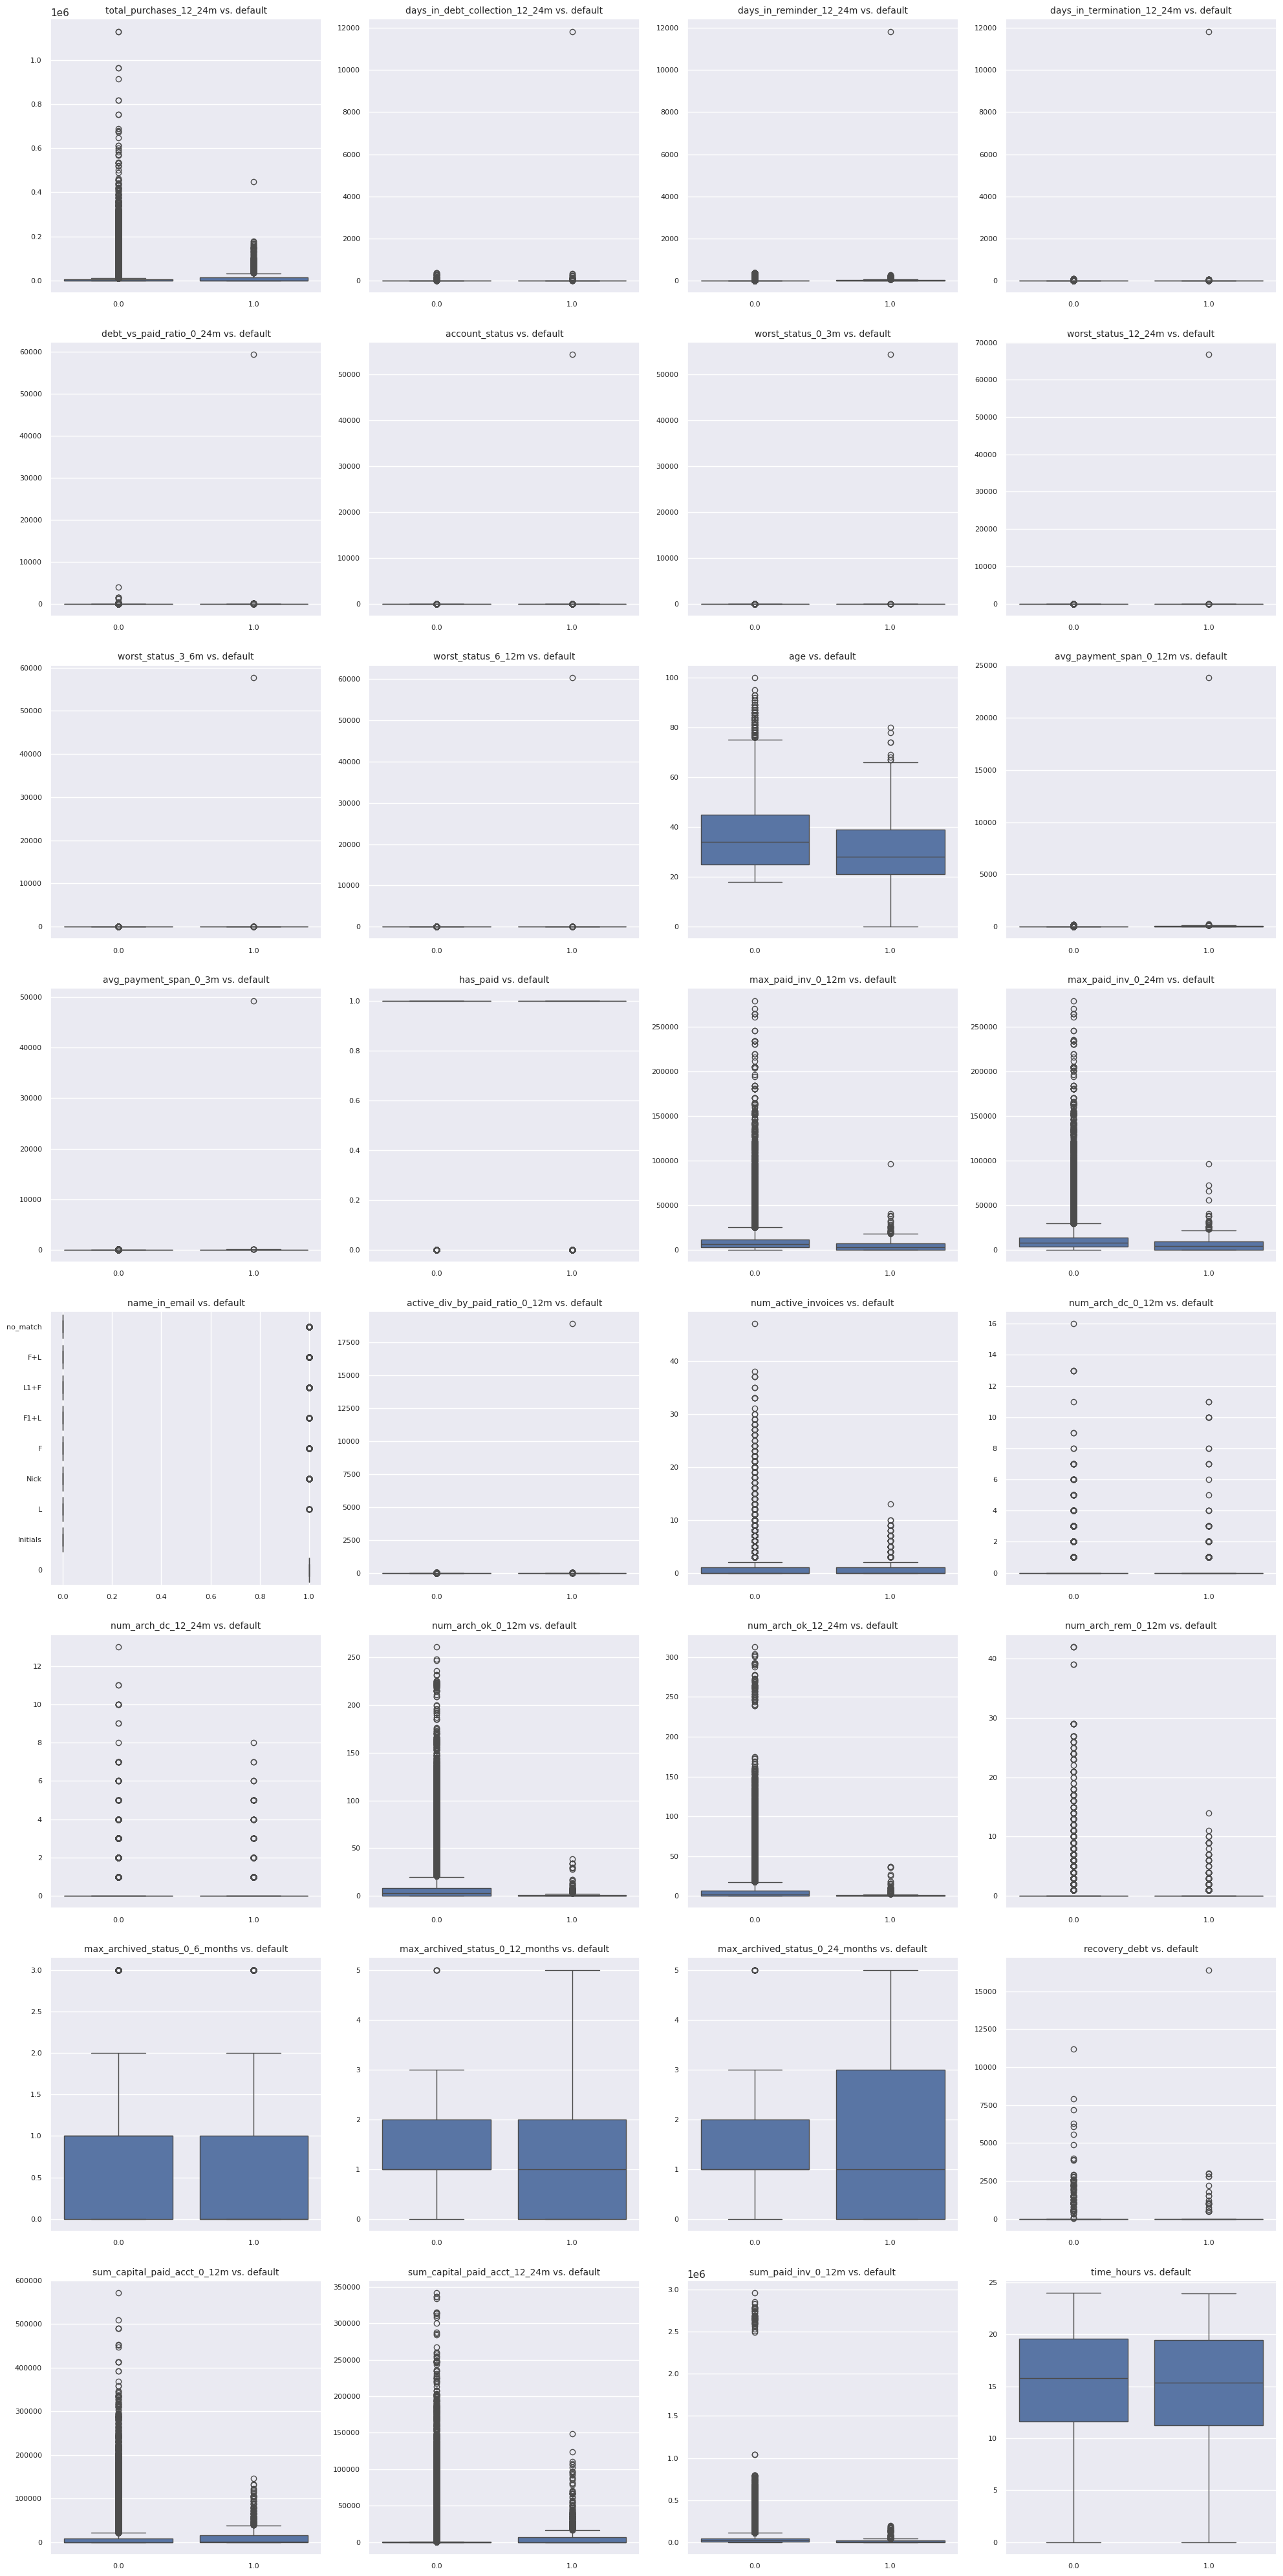

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

df['default'] = df['default'].replace(10000.0, 1.0)

target_variable = 'default'

variables_for_analysis = df.columns.tolist()
variables_for_analysis.remove(target_variable)
variables_for_analysis.remove('merchant_group')
variables_for_analysis.remove('userid')
variables_for_analysis.remove('merchant_category')

num_variables = len(variables_for_analysis)
num_cols = 4
num_rows = (num_variables + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5*num_rows))

axes = axes.flatten()

for i, variable in enumerate(variables_for_analysis):
    ax = axes[i]
    sns.boxplot(x=target_variable, y=variable, data=df, ax=ax)
    ax.set_title(f'{variable} vs. {target_variable}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', which='major', labelsize=8)

for i in range(num_variables, num_rows*num_cols):
    fig.delaxes(axes[i])

plt.tight_layout(h_pad=2)
plt.show()

In [42]:
df.drop(columns=['userid'], inplace=True)

In [43]:
df.head()

,default,total_purchases_12_24m,days_in_debt_collection_12_24m,days_in_reminder_12_24m,days_in_termination_12_24m,debt_vs_paid_ratio_0_24m,account_status,worst_status_0_3m,worst_status_12_24m,worst_status_3_6m,...,num_arch_ok_12_24m,num_arch_rem_0_12m,max_archived_status_0_6_months,max_archived_status_0_12_months,max_archived_status_0_24_months,recovery_debt,sum_capital_paid_acct_0_12m,sum_capital_paid_acct_12_24m,sum_paid_inv_0_12m,time_hours
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,NaN,1.0,...,14.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,178839.0,9.653333
1,0.0,0.0,0.0,0.0,0.0,NaN,1.0,1.0,1.0,1.0,...,19.0,3.0,1.0,2.0,2.0,0.0,0.0,0.0,49014.0,13.181389
2,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,0.0,3.0,1.0,2.0,2.0,0.0,0.0,0.0,124839.0,11.561944
3,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,324676.0,15.751111
4,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,7100.0,12.698611


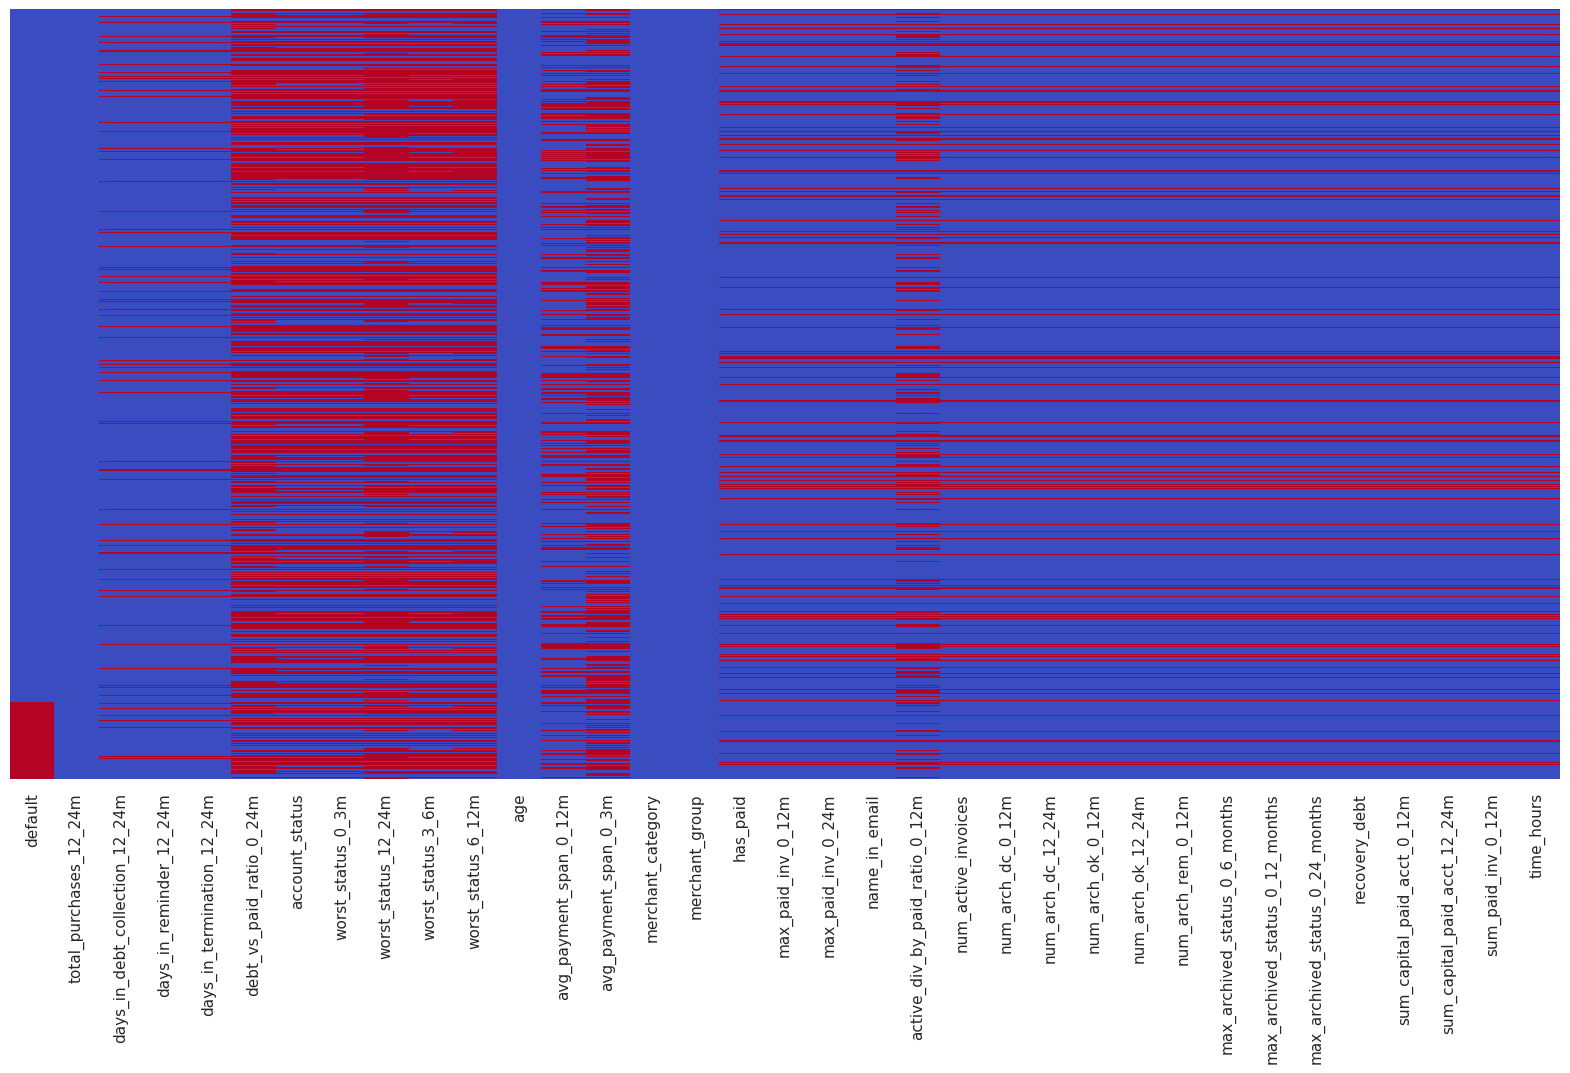

In [45]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.isnull(), cbar=False, cmap='coolwarm', yticklabels=False)
plt.show()

In [47]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

print("Missing Data Count in Ascending Order:")
missing_data_asc = missing_values.sort_values(ascending=True)
print(missing_data_asc)

print("\nPercentage of Missing Values for Each Column:")
print(missing_percentage)

Missing Data Count in Ascending Order:
total_purchases_12_24m                 2
merchant_category                      2
age                                    2
merchant_group                        11
default                            10002
num_arch_dc_0_12m                  11036
num_arch_dc_12_24m                 11036
num_arch_ok_0_12m                  11036
num_arch_ok_12_24m                 11036
num_arch_rem_0_12m                 11036
max_archived_status_0_6_months     11036
max_archived_status_0_12_months    11036
max_archived_status_0_24_months    11036
recovery_debt                      11036
sum_capital_paid_acct_0_12m        11036
sum_capital_paid_acct_12_24m       11036
num_active_invoices                11036
name_in_email                      11036
max_paid_inv_0_12m                 11036
sum_paid_inv_0_12m                 11036
has_paid                           11036
max_paid_inv_0_24m                 11036
time_hours                         11036
days_in_terminatio

In [48]:
missing_above_50 = missing_percentage[missing_percentage >= 50].index
df.drop(columns=missing_above_50, inplace=True)

In [49]:
print("Updated Shape of the Data:", df.shape)

Updated Shape of the Data: (99979, 29)


In [50]:
mean_values = df.select_dtypes(include='number').mean()

df.fillna(mean_values, inplace=True)

mode_values = df.select_dtypes(exclude='number').mode().iloc[0]

df.fillna(mode_values, inplace=True)

In [56]:
df.isnull().count()

default                            99979
total_purchases_12_24m             99979
days_in_debt_collection_12_24m     99979
days_in_reminder_12_24m            99979
days_in_termination_12_24m         99979
age                                99979
avg_payment_span_0_12m             99979
avg_payment_span_0_3m              99979
merchant_category                  99979
merchant_group                     99979
has_paid                           99979
max_paid_inv_0_12m                 99979
max_paid_inv_0_24m                 99979
name_in_email                      99979
active_div_by_paid_ratio_0_12m     99979
num_active_invoices                99979
num_arch_dc_0_12m                  99979
num_arch_dc_12_24m                 99979
num_arch_ok_0_12m                  99979
num_arch_ok_12_24m                 99979
num_arch_rem_0_12m                 99979
max_archived_status_0_6_months     99979
max_archived_status_0_12_months    99979
max_archived_status_0_24_months    99979
recovery_debt   

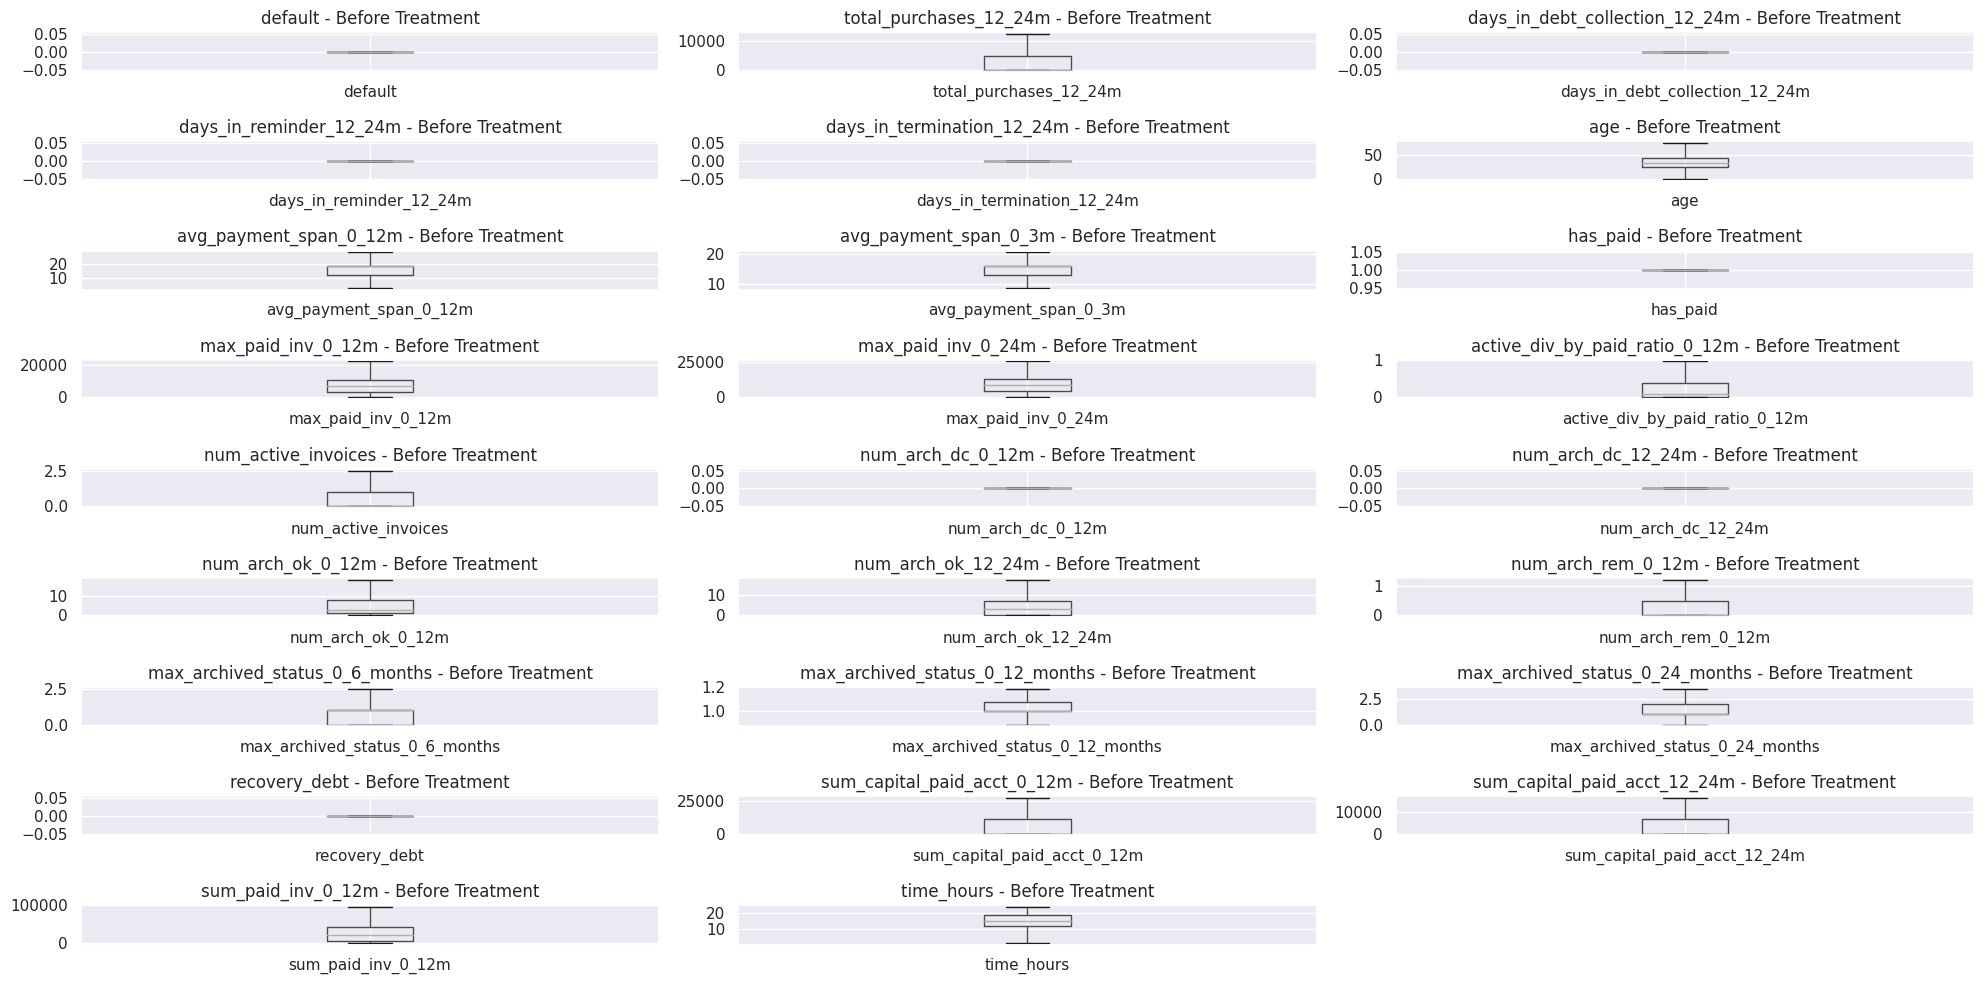

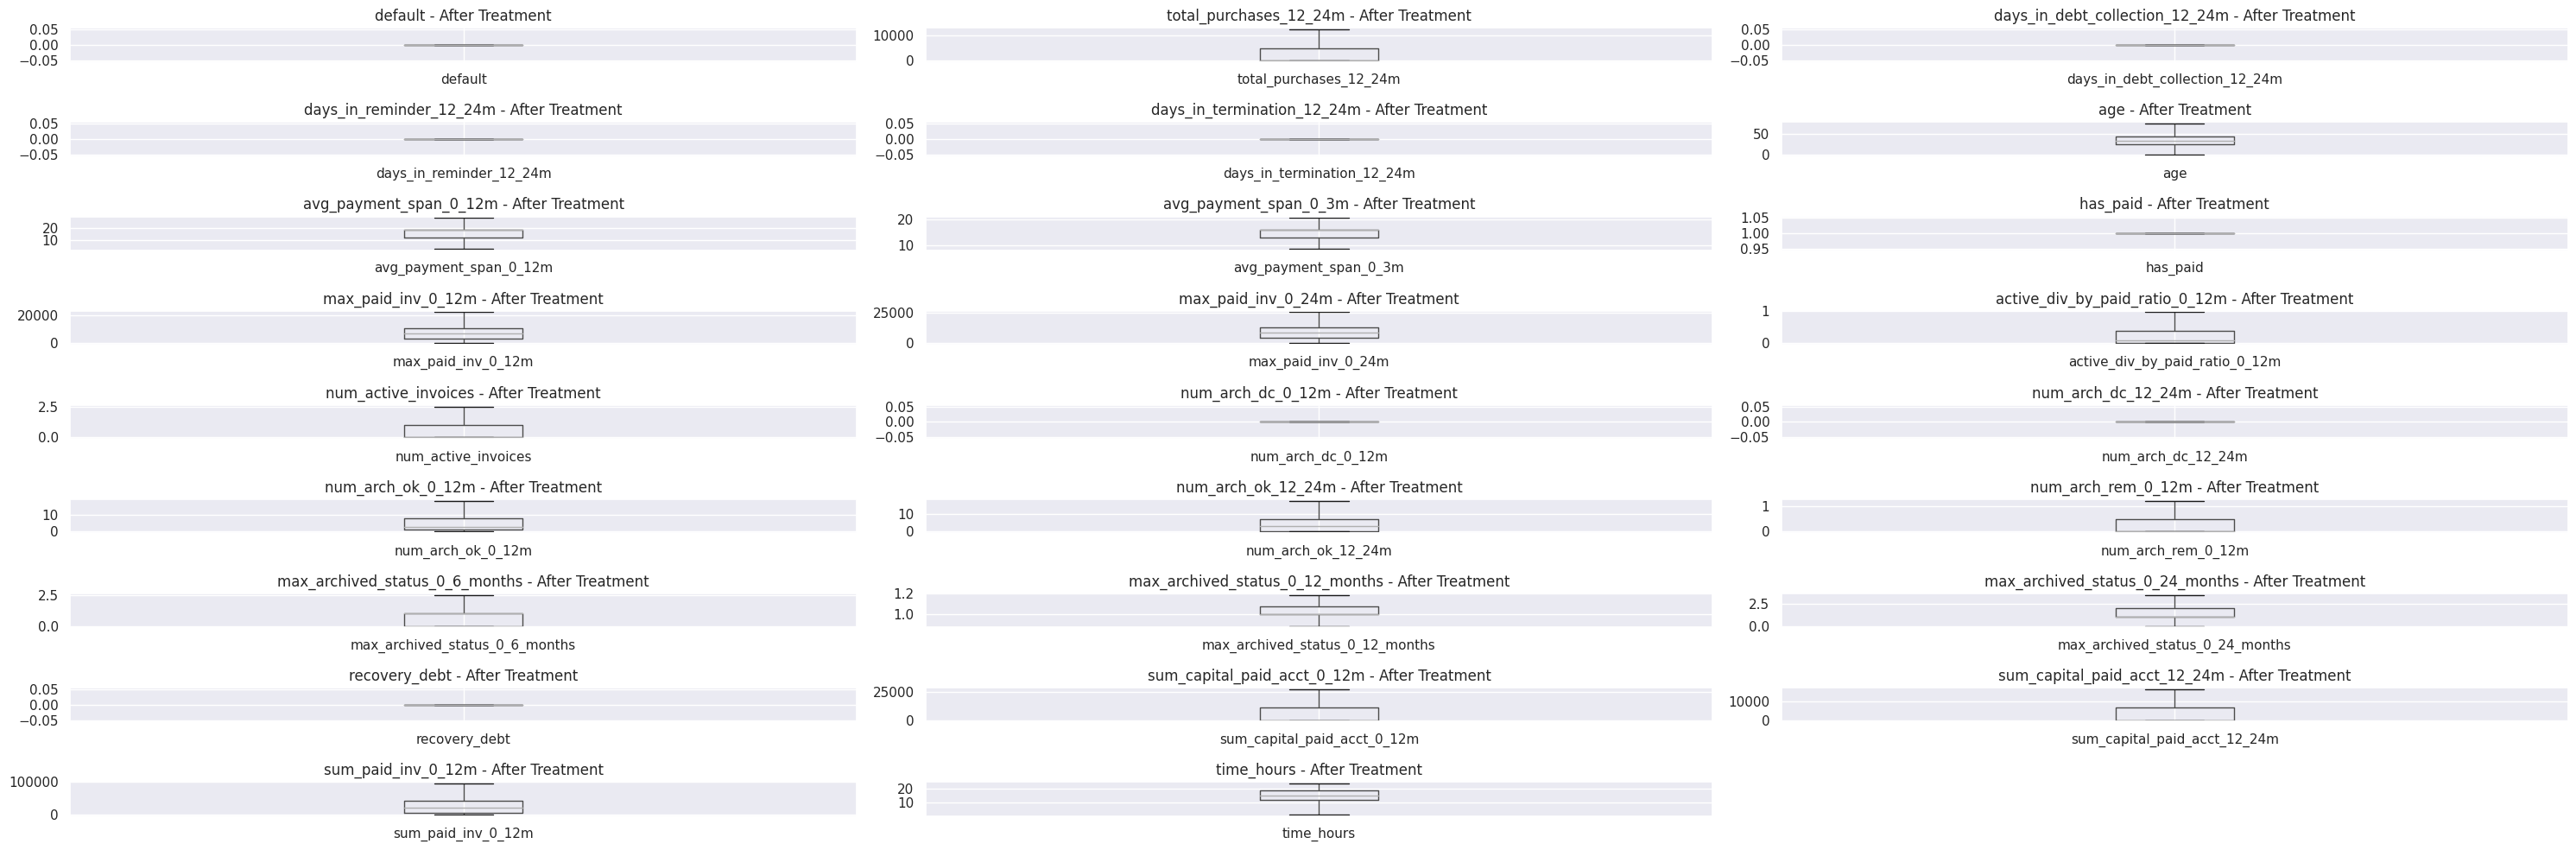

Column: default
Lower Bound: 0.0
Upper Bound: 0.0
Number of Outliers Detected: 0

Column: total_purchases_12_24m
Lower Bound: -7407.0
Upper Bound: 12345.0
Number of Outliers Detected: 0

Column: days_in_debt_collection_12_24m
Lower Bound: 0.0
Upper Bound: 0.0
Number of Outliers Detected: 0

Column: days_in_reminder_12_24m
Lower Bound: 0.0
Upper Bound: 0.0
Number of Outliers Detected: 0

Column: days_in_termination_12_24m
Lower Bound: 0.0
Upper Bound: 0.0
Number of Outliers Detected: 0

Column: age
Lower Bound: -5.0
Upper Bound: 75.0
Number of Outliers Detected: 0

Column: avg_payment_span_0_12m
Lower Bound: 2.6040540540540444
Upper Bound: 28.19324324324326
Number of Outliers Detected: 0

Column: avg_payment_span_0_3m
Lower Bound: 8.556231447518023
Upper Bound: 20.406280920803297
Number of Outliers Detected: 0

Column: has_paid
Lower Bound: 1.0
Upper Bound: 1.0
Number of Outliers Detected: 0

Column: max_paid_inv_0_12m
Lower Bound: -8380.0
Upper Bound: 21940.0
Number of Outliers Detecte

In [57]:
import matplotlib.pyplot as plt

def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers, lower_bound, upper_bound

treated_outliers = []

numerical_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    df.boxplot(column=col)
    plt.title(col + ' - Before Treatment')
plt.tight_layout()
plt.show()

for col in numerical_cols:
    outliers, lower_bound, upper_bound = detect_outliers_iqr(df[col])
    df[col][outliers] = np.nan
    treated_outliers.append({'Column': col, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound})

plt.figure(figsize=(30, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    df.boxplot(column=col)
    plt.title(col + ' - After Treatment')
plt.tight_layout()
plt.show()

for outlier_info in treated_outliers:
    print("Column:", outlier_info['Column'])
    print("Lower Bound:", outlier_info['Lower Bound'])
    print("Upper Bound:", outlier_info['Upper Bound'])
    print("Number of Outliers Detected:", df[outlier_info['Column']].isna().sum())
    print()


In [59]:
print(df.columns)

Index(['default', 'total_purchases_12_24m', 'days_in_debt_collection_12_24m',
       'days_in_reminder_12_24m', 'days_in_termination_12_24m', 'age',
       'avg_payment_span_0_12m', 'avg_payment_span_0_3m', 'merchant_category',
       'merchant_group', 'has_paid', 'max_paid_inv_0_12m',
       'max_paid_inv_0_24m', 'name_in_email', 'active_div_by_paid_ratio_0_12m',
       'num_active_invoices', 'num_arch_dc_0_12m', 'num_arch_dc_12_24m',
       'num_arch_ok_0_12m', 'num_arch_ok_12_24m', 'num_arch_rem_0_12m',
       'max_archived_status_0_6_months', 'max_archived_status_0_12_months',
       'max_archived_status_0_24_months', 'recovery_debt',
       'sum_capital_paid_acct_0_12m', 'sum_capital_paid_acct_12_24m',
       'sum_paid_inv_0_12m', 'time_hours', 'log_sum_paid_inv_0_12m'],
      dtype='object')


In [61]:
import pandas as pd
import numpy as np

df['log_sum_paid_inv_0_12m'] = np.log(df['sum_paid_inv_0_12m'])

df['total_purchases_12_24m'] = df['sum_paid_inv_0_12m'] + df['sum_paid_inv_0_12m']
df['active_div_by_paid_ratio_0_12m'] = df['num_active_invoices'] / df['sum_paid_inv_0_12m']
df['max_archived_status_0_6_months'] = df[['num_arch_dc_0_12m', 'num_arch_dc_12_24m', 'num_arch_ok_0_12m', 'num_arch_ok_12_24m', 'num_arch_rem_0_12m']].max(axis=1)
df['max_archived_status_0_12_months'] = df[['max_archived_status_0_6_months', 'max_archived_status_0_6_months']].max(axis=1)
df['max_archived_status_0_24_months'] = df[['max_archived_status_0_12_months', 'max_archived_status_0_12_months']].max(axis=1)

In [62]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99979 entries, 0 to 99978
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   default                          99979 non-null  float64
 1   total_purchases_12_24m           99979 non-null  float64
 2   days_in_debt_collection_12_24m   99979 non-null  float64
 3   days_in_reminder_12_24m          99979 non-null  float64
 4   days_in_termination_12_24m       99979 non-null  float64
 5   age                              99979 non-null  float64
 6   avg_payment_span_0_12m           99979 non-null  float64
 7   avg_payment_span_0_3m            99979 non-null  float64
 8   merchant_category                99979 non-null  object 
 9   merchant_group                   99979 non-null  object 
 10  has_paid                         99979 non-null  float64
 11  max_paid_inv_0_12m               99979 non-null  float64
 12  max_paid_inv_0_24m